In [ ]:
import re
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import seaborn as pd

# --- MOTOR MATEMÁTICO UNIVERSAL (N2-H2, O2, etc.) ---
def expand_vibrational_reactions(line_str):
    """
    Expande reacciones con rangos dinámicos (v=1:14), rangos dependientes (w=0:v-1),
    álgebra en productos (v=v+1) y protege especies de pared como wall_S(v).
    """
    # 1. Encontrar todos los bucles en la línea (ej. v=1:14, w=0:v-1)
    # Atrapa letra=inicio:fin (donde inicio y fin pueden tener matemáticas)
    loop_pattern = r'\b([a-z])=([a-z0-9\-+*]+):([a-z0-9\-+*]+)\b'
    loops = re.findall(loop_pattern, line_str)
    
    if not loops:
        return [line_str]
        
    expanded_lines = []
    
    # 2. Función recursiva para crear todas las combinaciones de variables
    def generate_envs(loop_list, current_env):
        if not loop_list:
            yield current_env
            return
        
        var, start_expr, end_expr = loop_list[0]
        
        # Diccionario seguro para evaluar matemáticas
        safe_dict = {"__builtins__": None}
        safe_dict.update(current_env)
        
        try:
            # Evaluamos dinámicamente. Si end_expr es 'v-1' y v=5, devuelve 4
            start_val = eval(start_expr, safe_dict)
            end_val = eval(end_expr, safe_dict)
        except Exception:
            start_val = int(start_expr)
            end_val = int(end_expr)
            
        # Si por las matemáticas el inicio es mayor que el fin (ej. w=0:v-1 si v=0), 
        # el range() simplemente estará vacío y no generará reacciones imposibles.
        for val in range(start_val, end_val + 1):
            next_env = current_env.copy()
            next_env[var] = val
            yield from generate_envs(loop_list[1:], next_env)

    # 3. Función inyectora que aplica las matemáticas solo a las especies correctas
    def replacer(match, env):
        species_base = match.group(1) # Ej: H2, N2
        expr = match.group(2).strip() # Ej: v=1:14, w=v-1, w=0, 44
        
        if '=' in expr:
            left, right = expr.split('=', 1)
            left = left.strip()
            right = right.strip()
        else:
            left = 'v'
            right = expr.strip()
            
        if ':' in right:
            # Es la definición de un bucle, tomamos el valor del entorno
            val = env.get(left, right)
        else:
            # Es un producto matemático (ej. w+1) o asignación estática (w=0)
            safe_dict = {"__builtins__": None}
            safe_dict.update(env)
            try:
                val = eval(right, safe_dict)
            except Exception:
                val = right 
                
        # Forzamos la normalización a la nomenclatura estándar
        return f"{species_base}(X,v={val})"

    # 4. Construimos las líneas expandidas
    for env in generate_envs(loops, {}):
        # La regex solo ataca a Especie(X,...). Ignora wall_S(v) o e.
        new_line = re.sub(r'([A-Za-z0-9_]+)\(X,([^)]+)\)', lambda m: replacer(m, env), line_str)
        expanded_lines.append(new_line)
        
    return expanded_lines

# --- FUNCIONES DE LECTURA ---
def parseChemFile(file):
    with open(file, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    uniqueSpecies = []
    reactions = []
    
    for line in lines:
        cleanLine = line.strip()
        if not cleanLine or cleanLine.startswith('%'):
            continue
            
        reaction_str_raw = cleanLine.split('|')[0].strip()
        if not reaction_str_raw:
            continue
            
        # ¡Llamamos al motor universal!
        expanded_reaction_strings = expand_vibrational_reactions(reaction_str_raw)
        
        for react_str in expanded_reaction_strings:
            try:
                reaction = parseReactionStr(react_str)
            except ValueError:
                continue
            
            if reaction not in reactions:
                reactions.append(reaction)
                
            for species in reaction['lhsSpecies'] + reaction['rhsSpecies']:
                if species not in uniqueSpecies:
                    uniqueSpecies.append(species)

    return uniqueSpecies, reactions

def parseReactionStr(reactionStr):
    if '<->' in reactionStr:
        backwardReaction = True
        lhsStr, rhsStr = reactionStr.split('<->')
    elif '->' in reactionStr:
        backwardReaction = False
        lhsStr, rhsStr = reactionStr.split('->')
    else:
        raise ValueError(f"Formato inválido: {reactionStr}")
    
    lhsSpecies, lhsStoic = parseSpeciesStr(lhsStr)
    rhsSpecies, rhsStoic = parseSpeciesStr(rhsStr)
    
    return {
        'description': reactionStr,
        'lhsSpecies': lhsSpecies,
        'lhsStoichiometricCoeffs': lhsStoic,
        'rhsSpecies': rhsSpecies,
        'rhsStoichiometricCoeffs': rhsStoic,
        'backwardReaction': backwardReaction
    }

def parseSpeciesStr(species_string):
    species_list = []
    coeff_list = []
    parts = species_string.strip().split(' + ')
    
    for part in parts:
        part = part.strip()
        if not part: continue
        
        match = re.match(r'^(\d*\.?\d*)(.+)$', part)
        if match:
            coeff_str = match.group(1)
            species = match.group(2).strip()
            
            coeff = float(coeff_str) if '.' in coeff_str else int(coeff_str) if coeff_str else 1
            
            if species not in species_list:
                species_list.append(species)
                coeff_list.append(coeff)
            else:
                idx = species_list.index(species)
                coeff_list[idx] += coeff

    return species_list, coeff_list

# --- PROGRAMA PRINCIPAL ---
if __name__ == "__main__":
    archivo = 'N2H2_CS14_Q5_H5.chem'
    print(f"Iniciando análisis avanzado del plasma ({archivo})...")
    
    uniqueSpecies, reactions = parseChemFile(archivo)

    print(f"\n✅ Análisis completado con éxito.")
    print(f"📊 Especies Únicas Encontradas: {len(uniqueSpecies)}")
    print(f"💥 Número total de Reacciones (Expandidas): {len(reactions)}")
    
    print('\n--- Ejemplos de Reacciones Expandidas V-V (H2) ---')
    # Filtramos algunas reacciones de hidrógeno para comprobar que el álgebra funciona
    h2_vv_reactions = [r for r in reactions if 'H2(X,v=10)' in r['lhsSpecies'] and len(r['lhsSpecies']) > 1]
    
    for r in h2_vv_reactions[:3]:  # Mostramos solo las 3 primeras como prueba
        print(f"R: {r['description']}")

Iniciando análisis avanzado del plasma (N2H2_CS14_Q5_H5.chem)...

✅ Análisis completado con éxito.
📊 Especies Únicas Encontradas: 108
💥 Número total de Reacciones (Expandidas): 4823

--- Ejemplos de Reacciones Expandidas V-V (H2) ---
R: e + H2(X,v=10) -> e + H2(X,v=0)
R: e + H2(X,v=10) -> e + H2(X,v=1)
R: e + H2(X,v=10) -> e + H2(X,v=2)


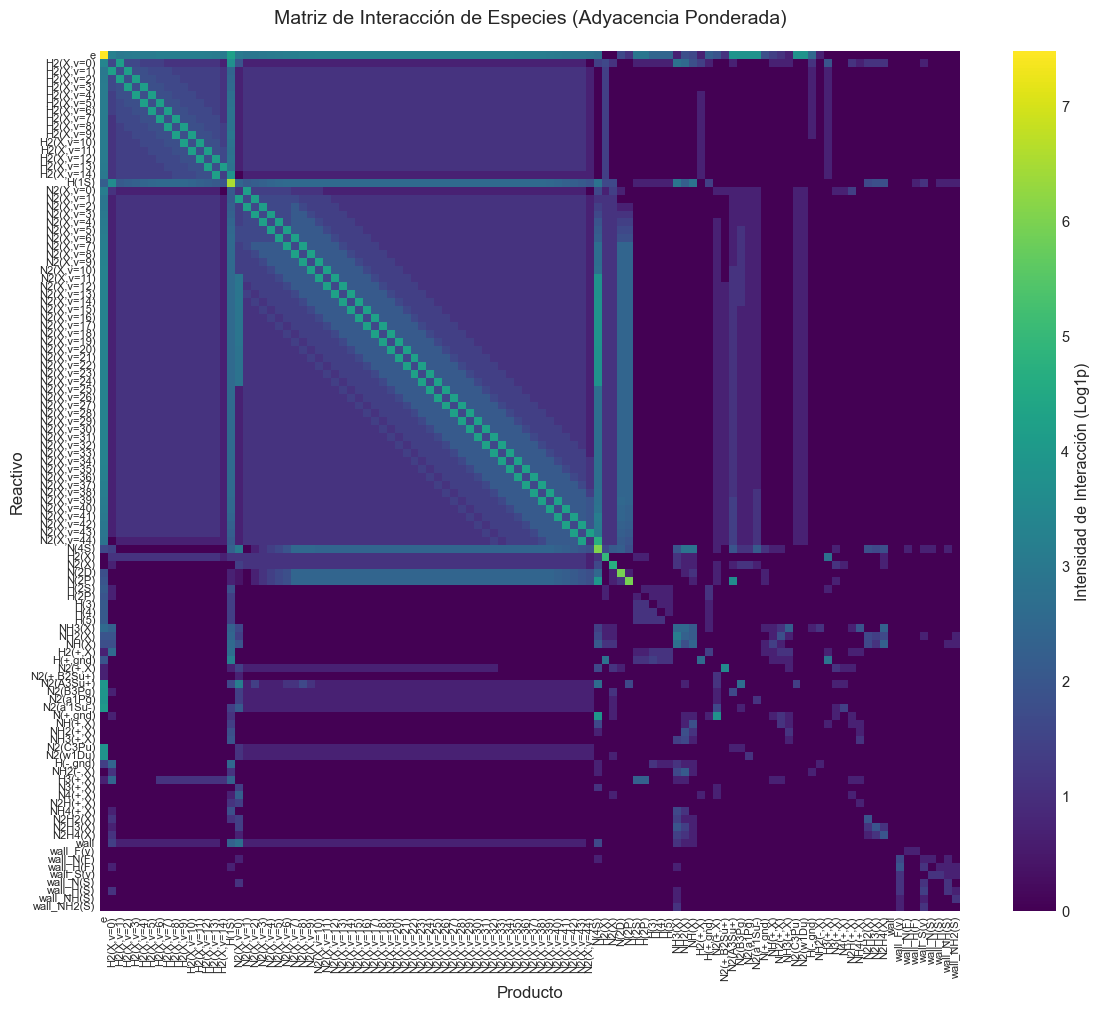

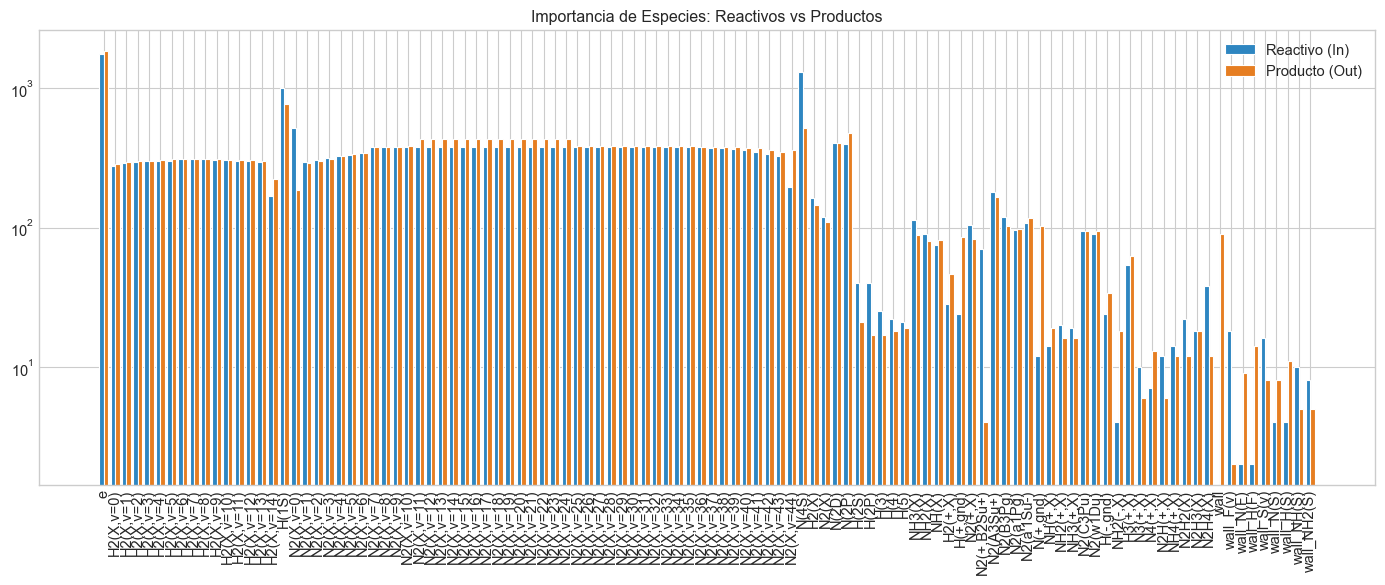

Se han detectado 9 comunidades químicas en N2-H2.
Grupo 1: {'N2(C3Pu)', 'N2(A3Su+)', 'H(4)', 'N2(a1Pg)', "N2(a'1Su-)", 'e', 'N2(w1Du)', 'H(2S)', 'N2(B3Pg)', 'H(3)', 'H(2P)', 'H(5)'}
Grupo 2: {'H2(X,v=2)', 'H2(X,v=3)', 'H2(X,v=5)', 'H2(X,v=4)', 'H2(X,v=9)', 'H2(X,v=7)', 'H2(X,v=10)', 'H2(X,v=11)', 'H2(X,v=6)', 'H2(X,v=1)', 'H2(X,v=13)', 'H2(X,v=8)', 'H2(X,v=14)', 'H2(X,v=12)'}
Grupo 3: {'N2(X,v=3)', 'N4(+,X)', 'N2(X,v=0)', 'N2(X,v=2)', 'N2(X,v=8)', 'N2(X,v=11)', 'N2(X,v=7)', 'N2(X,v=10)', 'N2(X,v=9)', 'N2(X,v=5)', 'wall', 'N2(X,v=4)', 'N2(X,v=12)', 'N2(X,v=1)', 'N2(X,v=6)'}
Grupo 4: {'N2(X,v=13)', 'N2(X,v=24)', 'N2(X,v=15)', 'N(4S)', 'N2(X,v=18)', 'N2(X,v=21)', 'N2(X,v=20)', 'N2(X,v=17)', 'N2(X,v=16)', 'N2(X,v=14)', 'N2(X,v=22)', 'N2(X,v=19)', 'N2(X,v=23)'}
Grupo 5: {'N2(X,v=27)', 'N2(X,v=33)', 'N2(X,v=25)', 'N(2D)', 'N2(X,v=32)', 'N2(X,v=26)', 'N2(X,v=30)', 'N2(X,v=29)', 'N2(X,v=28)', 'N2(X,v=31)'}
Grupo 6: {'N(2P)'}
Grupo 7: {'N2(X,v=35)', 'N2(X,v=43)', 'N2(X,v=34)', 'N2(X,v=42)', 'N2

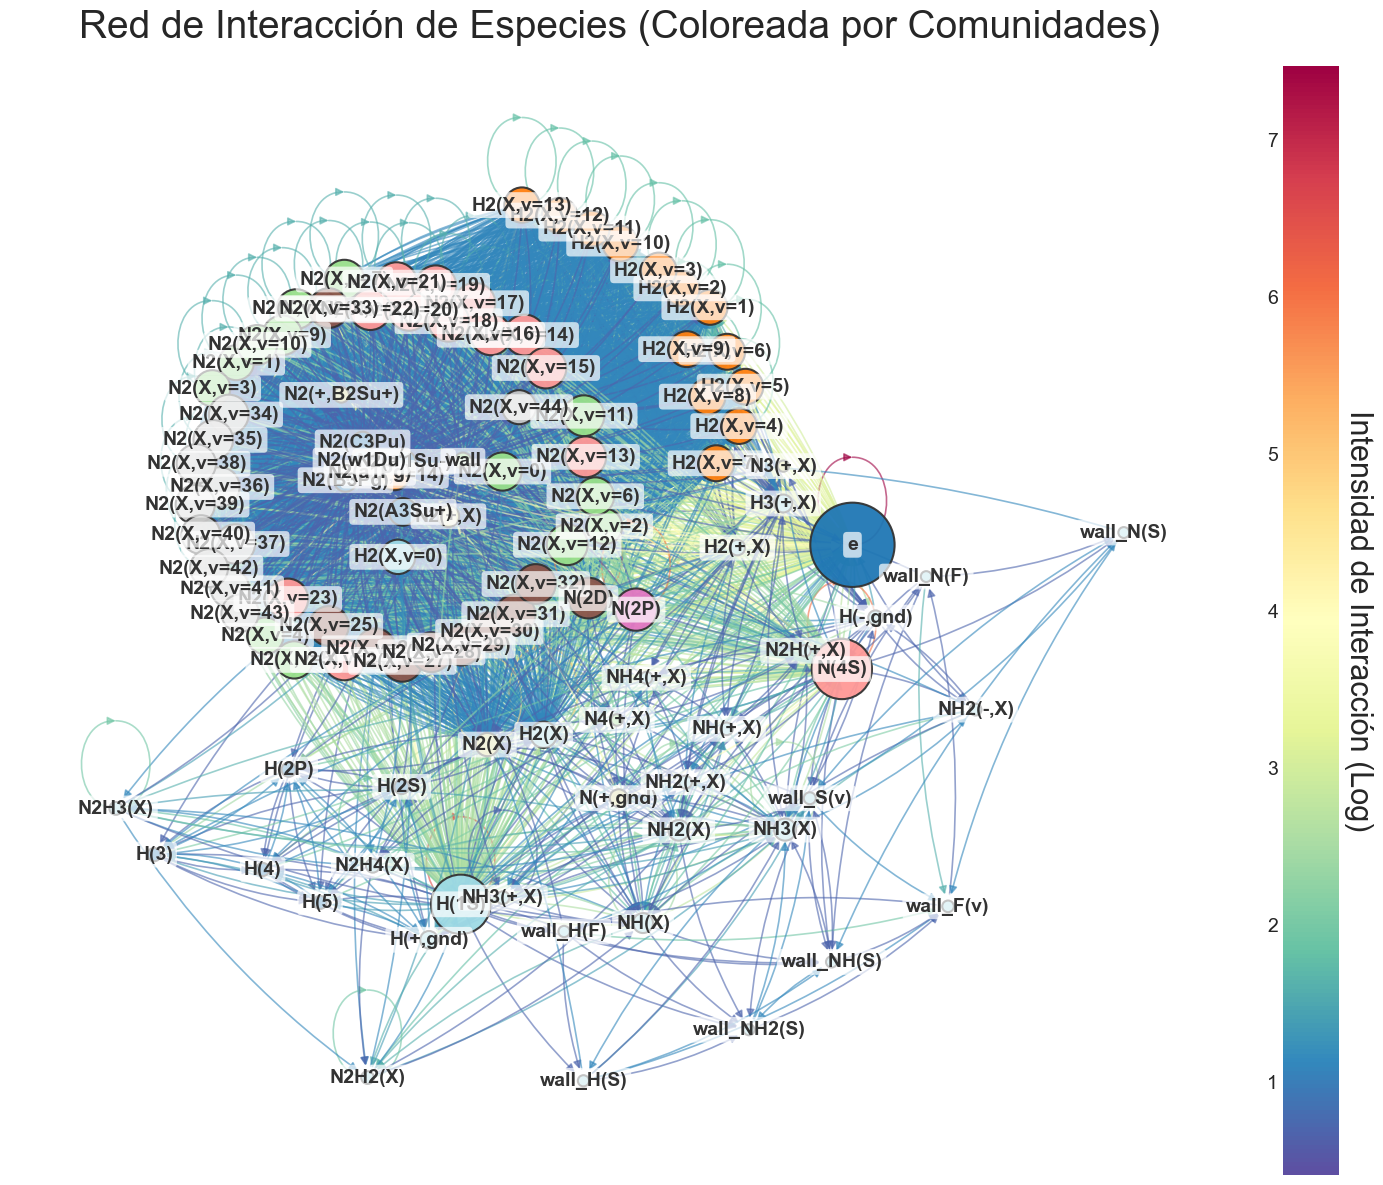

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from networkx.algorithms import community

uniqueSpecies, reactions = parseChemFile('N2H2_CS14_Q5_H5.chem')
G = nx.DiGraph()
G.add_nodes_from(uniqueSpecies)

for r in reactions:
    # Sentido directo
    for src in r['lhsSpecies']:
        for dst in r['rhsSpecies']:
            w = r['lhsStoichiometricCoeffs'][r['lhsSpecies'].index(src)] * \
                r['rhsStoichiometricCoeffs'][r['rhsSpecies'].index(dst)]
            if G.has_edge(src, dst): G[src][dst]['weight'] += w
            else: G.add_edge(src, dst, weight=w)
    # Sentido inverso
    if r['backwardReaction']:
        for src in r['rhsSpecies']:
            for dst in r['lhsSpecies']:
                w = r['rhsStoichiometricCoeffs'][r['rhsSpecies'].index(src)] * \
                    r['lhsStoichiometricCoeffs'][r['lhsSpecies'].index(dst)]
                if G.has_edge(src, dst): G[src][dst]['weight'] += w
                else: G.add_edge(src, dst, weight=w)

# --- 3. VISUALIZACIONES ---

# --- A. MATRIZ DE ADYACENCIA PROFESIONAL ---
# 1. Crear la matriz
orden_nodos = list(G.nodes)
vector_nodos = np.array(orden_nodos)
np.save('orden_nodos_n2h2.npy', vector_nodos)
matriz_adyacencia = nx.to_numpy_array(G, nodelist=orden_nodos)

# 2. Crear un DataFrame de Pandas para tener etiquetas automáticas
df_adj = pd.DataFrame(np.log1p(matriz_adyacencia), 
                      index=orden_nodos, 
                      columns=orden_nodos)

# 3. Graficar con Seaborn
plt.figure(figsize=(12, 10)) 
sns.heatmap(df_adj, 
            cmap='viridis',      
            xticklabels=True,    
            yticklabels=True,
            cbar_kws={'label': 'Intensidad de Interacción (Log1p)'},
            square=True)         

plt.title('Matriz de Interacción de Especies (Adyacencia Ponderada)', fontsize=14, pad=20)
plt.xlabel('Producto', fontsize=12)
plt.ylabel('Reactivo', fontsize=12)

plt.xticks(rotation=90, fontsize=8) 
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


# --- B. Comparación Grados de Entrada/Salida ---
in_deg = [np.sum(matriz_adyacencia[:, i]) - matriz_adyacencia[i,i] for i in range(len(orden_nodos))]
out_deg = [np.sum(matriz_adyacencia[i, :]) - matriz_adyacencia[i,i] for i in range(len(orden_nodos))]
x = np.arange(len(orden_nodos))

plt.figure(figsize=(14, 6))
plt.bar(x - 0.2, in_deg, 0.4, label='Reactivo (In)', color='#2E86C1', log=True)
plt.bar(x + 0.2, out_deg, 0.4, label='Producto (Out)', color='#E67E22', log=True)
plt.xticks(x, orden_nodos, rotation=90)
plt.legend()
plt.title('Importancia de Especies: Reactivos vs Productos')
plt.tight_layout()
plt.savefig('grados_N2H2.png')
plt.show()


# --- C. Proyección de la Red ---

# 1. PREPARACIÓN DE DATOS 
pos = nx.kamada_kawai_layout(G)

# Tamaños basados en grado
grado_total = [in_deg[i] + out_deg[i] for i in range(len(orden_nodos))]
np.save('grado_total_n2h2.npy', grado_total)
node_sizes = [50 +  g for g in grado_total] 

# Pesos logarítmicos para el color de las aristas
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
weights_log = np.log1p(weights) 

# --- CÁLCULO DE COMUNIDADES ---
comunidades = community.louvain_communities(G, weight='weight', seed=123)
print(f"Se han detectado {len(comunidades)} comunidades químicas en N2-H2.")
for i, comm in enumerate(comunidades):
    print(f"Grupo {i+1}: {comm}")

# Mapeamos a cada nodo el número de su comunidad
mapa_comunidades = {}
for i, comm in enumerate(comunidades):
    for nodo in comm:
        mapa_comunidades[nodo] = i

# Creamos la lista de colores (números) en el mismo orden exacto que los nodos
node_color_values = [mapa_comunidades[nodo] for nodo in G.nodes()]


# 2. CONFIGURACIÓN DE LA FIGURA 
plt.style.use('seaborn-v0_8-whitegrid') 
fig, ax = plt.subplots(figsize=(14, 12), dpi=100) 

# 3. DIBUJAR ARISTAS 
edges_drawn = nx.draw_networkx_edges(G, pos,
                       ax=ax,
                       edgelist=edges,
                       edge_color=weights_log,
                       edge_cmap=plt.cm.Spectral_r, 
                       width=1.2,
                       alpha=0.6,
                       arrowsize=12,
                       arrowstyle='-|>', 
                       connectionstyle="arc3,rad=0.1") 

# 4. DIBUJAR NODOS (AHORA CON COLORES DE COMUNIDAD)
nx.draw_networkx_nodes(G, pos,
                       ax=ax,
                       node_size=node_sizes,
                       node_color=node_color_values,  # <-- Inyectamos las comunidades
                       cmap=plt.cm.tab20,             
                       edgecolors='#333333', 
                       linewidths=1.5,       
                       alpha=0.95)

# 5. DIBUJAR ETIQUETAS 
pos_labels = {k: (v[0], v[1]) for k, v in pos.items()} 

labels = nx.draw_networkx_labels(G, pos_labels,
                         ax=ax,
                         font_size=14,                 
                         font_family='sans-serif',
                         font_weight='bold',
                         font_color='#333333')

# Añadir un "halo" a las etiquetas
for t in labels.values():
    t.set_bbox(dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))

# 6. BARRA DE COLOR Y DETALLES FINALES 
sm = plt.cm.ScalarMappable(cmap=plt.cm.Spectral_r, norm=plt.Normalize(vmin=min(weights_log), vmax=max(weights_log)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Intensidad de Interacción (Log)', rotation=270, labelpad=25, fontsize=22) 
cbar.outline.set_visible(False) 

ax.set_title("Red de Interacción de Especies (Coloreada por Comunidades)", fontsize=28, pad=20)
ax.axis('off') 

plt.tight_layout()
plt.savefig('red_comunidades_N2H2.png', dpi=300) 
plt.show()

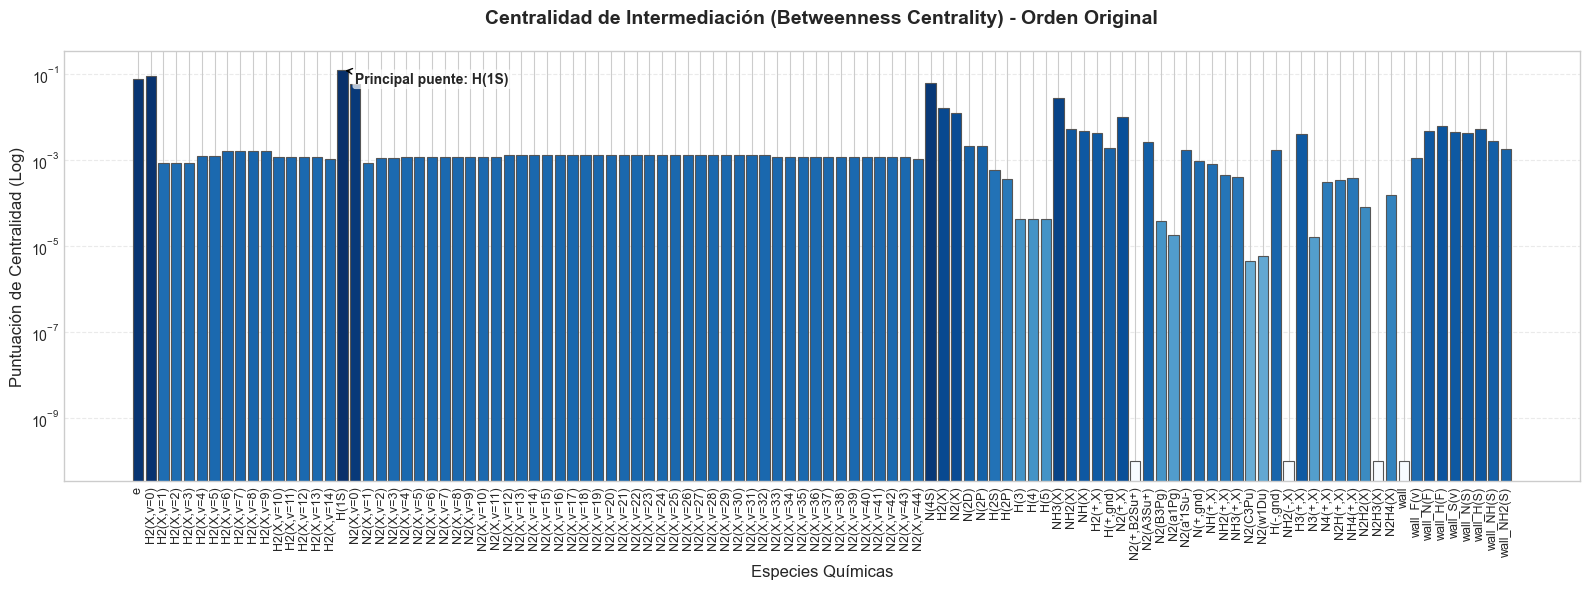

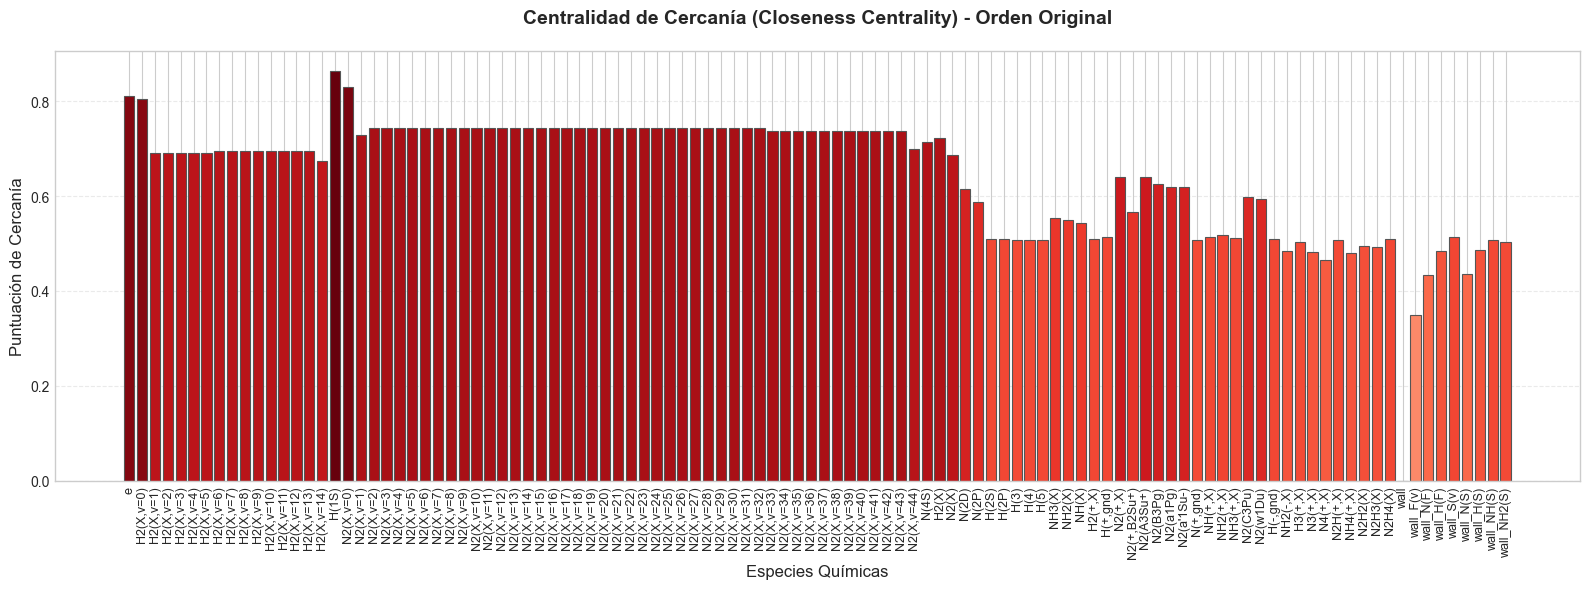

In [ ]:
import networkx as nx 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.colors as mcolors  
from networkx.algorithms import community


# =============================================================================
# 1. CENTRALIDAD DE INTERMEDIACIÓN (BETWEENNESS) - ORDEN ORIGINAL Y CORREGIDO
# =============================================================================
centrality = nx.betweenness_centrality(G)
np.save('centralidad_b_N2H2.npy', list(centrality.values()))

# Extraemos los nodos y valores manteniendo el ORDEN ORIGINAL del grafo
nodes_b = list(G.nodes())
values_b = list(centrality.values())

plt.figure(figsize=(16, 6))

# Evitamos ceros puros para que el logaritmo y el degradado no den error
values_b_plot = [v if v > 0 else 1e-10 for v in values_b]

# Normalización logarítmica para los colores 
norm_b = mcolors.LogNorm(vmin=min(values_b_plot), vmax=max(values_b_plot))
colors_b = plt.cm.Blues(norm_b(values_b_plot))

# Dibujamos las barras 
plt.bar(nodes_b, values_b_plot, color=colors_b, edgecolor='#555555', linewidth=0.8)
plt.yscale('log') 

plt.title('Centralidad de Intermediación (Betweenness Centrality) - Orden Original', fontsize=14, pad=20, fontweight='bold')
plt.ylabel('Puntuación de Centralidad (Log)', fontsize=12)
plt.xlabel('Especies Químicas', fontsize=12)

plt.xticks(rotation=90, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Encontrar automáticamente el nodo TOP 1 para ponerle la flecha
max_idx_b = np.argmax(values_b)
max_val_b = values_b_plot[max_idx_b]

# Resaltar el Top 1 donde quiera que esté en el eje X
plt.annotate(f'Principal puente: {nodes_b[max_idx_b]}', 
             xy=(max_idx_b, max_val_b), 
             xytext=(max_idx_b + 1, max_val_b * 0.5), 
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, fontweight='bold',
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.savefig('histograma_betweenness_oxigeno.png', dpi=300) 
plt.show()


# =============================================================================
# 2. CENTRALIDAD DE CERCANÍA (CLOSENESS) - ORDEN ORIGINAL
# =============================================================================
closeness_centrality = nx.closeness_centrality(G)
np.save('centralidad_c_N2H2.npy', list(closeness_centrality.values()))

# Extraemos los nodos y valores manteniendo el ORDEN ORIGINAL
nodes_c = list(G.nodes())
values_c = list(closeness_centrality.values())

plt.figure(figsize=(16, 6))

# Paleta cálida basada en la altura
norm_c = plt.Normalize(vmin=min(values_c), vmax=max(values_c))
colors_c = plt.cm.Reds(norm_c(values_c))

# Dibujamos las barras 
plt.bar(nodes_c, values_c, color=colors_c, edgecolor='#555555', linewidth=0.8)

# Ajustamos el rango Y para que se vea perfectamente la diferencia de alturas
plt.ylim(min(values_c) * 0.95, max(values_c) * 1.05) 

plt.title('Centralidad de Cercanía (Closeness Centrality) - Orden Original', fontsize=14, pad=20, fontweight='bold')
plt.ylabel('Puntuación de Cercanía', fontsize=12)
plt.xlabel('Especies Químicas', fontsize=12)

plt.xticks(rotation=90, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('histograma_closeness_oxigeno.png', dpi=300) 
plt.show()

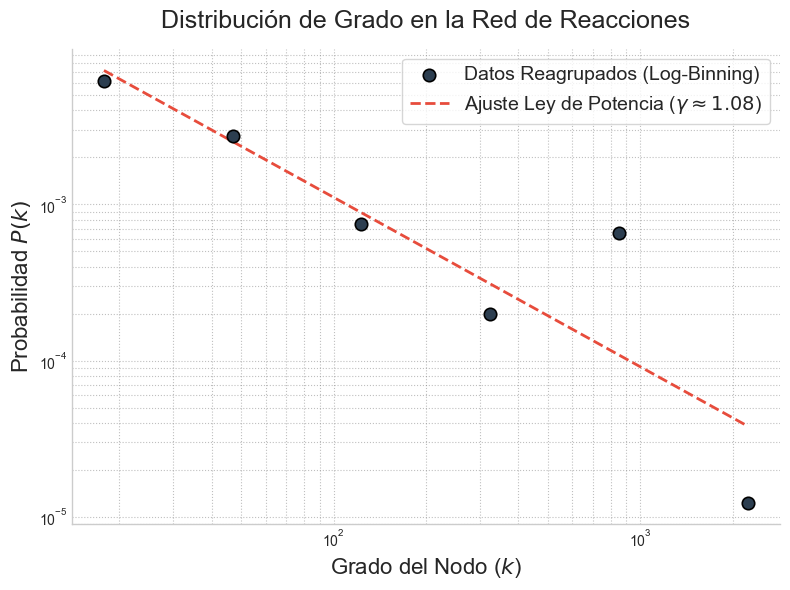

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- FUNCIÓN DE LOG-BINNING ---
def logarithmic_binning(grados, n_bins=50): 
    grados = np.array(grados)
    grados = grados[grados > 0]
    min_exp, max_exp = np.log10(min(grados)), np.log10(max(grados))
    bins = np.logspace(min_exp, max_exp, num=n_bins)
    counts, edges = np.histogram(grados, bins=bins, density=False)
    bin_widths = np.diff(edges)
    bin_centers = np.sqrt(edges[:-1] * edges[1:])
    density = counts / (bin_widths * len(grados))
    mask = density > 0
    return bin_centers[mask], density[mask]

# 1. Procesamiento de datos
x_binned, y_binned = logarithmic_binning(grado_total, n_bins=7)

# 2. Ajuste Lineal en espacio logarítmico
log_x, log_y = np.log10(x_binned), np.log10(y_binned)
def linear_model(x, m, c): return m * x + c
popt, _ = curve_fit(linear_model, log_x, log_y)
gamma = -popt[0] # El exponente de la ley de potencias

# --- GRÁFICA PROFESIONAL ---
plt.figure(figsize=(8, 6))

# Dibujar solo los datos agrupados 
plt.scatter(x_binned, y_binned, 
            color='#2c3e50',      
            s=80, 
            edgecolors='black', 
            linewidths=1.2,
            label='Datos Reagrupados (Log-Binning)',
            zorder=3)

# Línea de ajuste
x_line = np.logspace(np.log10(min(x_binned)), np.log10(max(x_binned)), 100)
y_line = (10**popt[1]) * (x_line**popt[0])
plt.plot(x_line, y_line, 
         color='#e74c3c',         
         linestyle='--', 
         linewidth=2, 
         label=rf'Ajuste Ley de Potencia ($\gamma \approx {gamma:.2f}$)',
         zorder=2)

# Configuración de Ejes
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Grado del Nodo ($k$)', fontsize=16)
plt.ylabel(r'Probabilidad $P(k)$', fontsize=16)
plt.title('Distribución de Grado en la Red de Reacciones', fontsize=18, pad=15)

# Mejorar la rejilla y el marco
plt.grid(True, which="both", ls=":", alpha=0.5, color='gray')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Leyenda y Anotación técnica
plt.legend(frameon=True, loc='upper right', fontsize=14)
plt.tight_layout()

plt.show()